Dataset Shape: (85907, 20)
Training samples: 68725, Features: 2
Epoch 1/50
3437/3437 ━━━━━━━━━━━━━━━━━━━━ 28s 7ms/step - accuracy: 0.8236 - loss: 0.4664 - val_accuracy: 0.8219 - val_loss: 0.4649
Epoch 2/50
3437/3437 ━━━━━━━━━━━━━━━━━━━━ 25s 7ms/step - accuracy: 0.8240 - loss: 0.4601 - val_accuracy: 0.8206 - val_loss: 0.4653
Epoch 3/50
3437/3437 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - accuracy: 0.8240 - loss: 0.4599 - val_accuracy: 0.8223 - val_loss: 0.4643
Epoch 4/50
3437/3437 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - accuracy: 0.8240 - loss: 0.4597 - val_accuracy: 0.8223 - val_loss: 0.4654
Epoch 5/50
3437/3437 ━━━━━━━━━━━━━━━━━━━━ 40s 7ms/step - accuracy: 0.8242 - loss: 0.4591 - val_accuracy: 0.8216 - val_loss: 0.4655
Epoch 6/50
3437/3437 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - accuracy: 0.8243 - loss: 0.4593 - val_accuracy: 0.8223 - val_loss: 0.4643
Epoch 7/50
3437/3437 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - accuracy: 0.8242 - loss: 0.4594 - val_accuracy: 0.8223 - val_loss: 0.4642
Epoch 8/50
3437/343

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 32)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,925 (7.52 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,284 (5.02 KB)

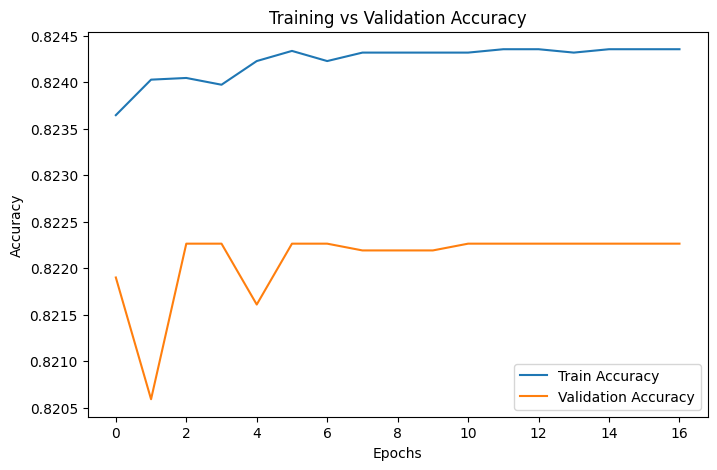

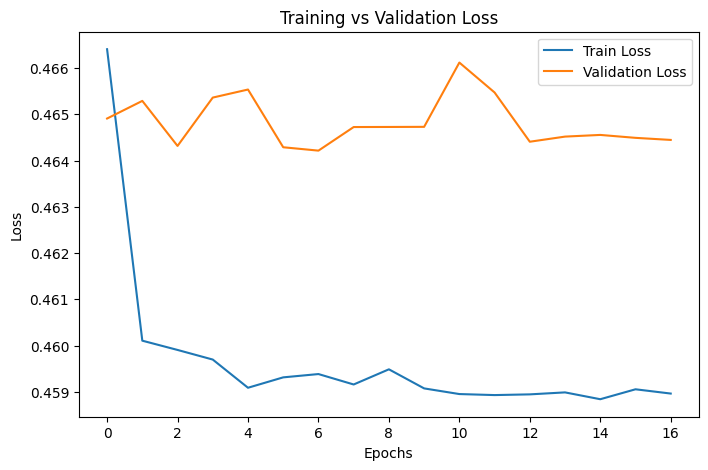

537/537 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
📌 FORMATTED CLASSIFICATION REPORT


,precision,recall,f1-score,support
0,0.000,0.000,0.000,2971.000
1,0.827,1.000,0.905,14211.000
accuracy,0.827,0.827,0.827,0.827
macro avg,0.414,0.500,0.453,17182.000
weighted avg,0.684,0.827,0.749,17182.000


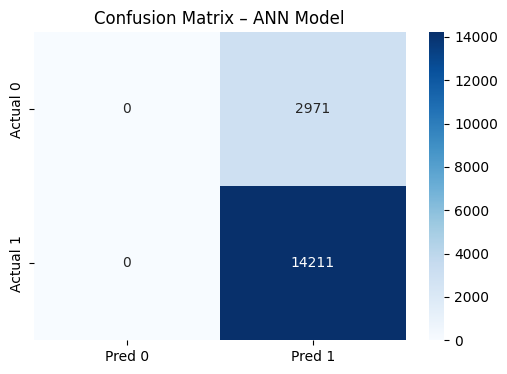

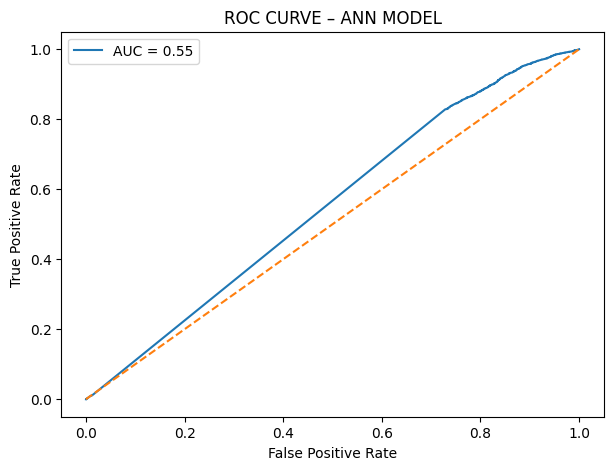

ROC-AUC Score: 0.5518


'\nimport shap\nexplainer = shap.KernelExplainer(model.predict, X_train[:100])\nshap_values = explainer.shap_values(X_test[:10])\nshap.summary_plot(shap_values, X_test[:10])\n'

In [5]:
# ===========================================================
# 📘 WEEK 9 – ARTIFICIAL NEURAL NETWORK (ANN) FOR E-COMMERCE CSAT
# ===========================================================

# 1️⃣ Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

# ===========================================================
# 2️⃣ LOAD DATA
# ===========================================================
df = pd.read_csv("Customer_support_data.csv")

print("Dataset Shape:", df.shape)
df.head(3)

# ===========================================================
# 3️⃣ DATA PREPROCESSING
# ===========================================================
id_cols = [c for c in df.columns if 'id' in c.lower() or 'uuid' in c.lower()]
df.drop(columns=id_cols, inplace=True, errors='ignore')

num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].apply(lambda col: col.fillna(col.median()))

cat_cols = df.select_dtypes(include='object').columns
low_cardinality = [c for c in cat_cols if df[c].nunique() < 20]
df = pd.get_dummies(df, columns=low_cardinality, drop_first=True)
df.drop(columns=df.select_dtypes(exclude=[np.number]).columns, inplace=True, errors='ignore')

df['CSAT_Category'] = df['CSAT Score'].apply(lambda x: 1 if x >= 4 else 0)

X = df.drop(columns=['CSAT Score', 'CSAT_Category'], errors='ignore')
y = df['CSAT_Category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Training samples: {X_train.shape[0]}, Features: {X_train.shape[1]}")

# ===========================================================
# 4️⃣ BUILD ANN MODEL
# ===========================================================
model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# ===========================================================
# 5️⃣ TRAIN ANN
# ===========================================================
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

# ===========================================================
# 6️⃣ MODEL SUMMARY
# ===========================================================
print("ANN Model Summary")
model.summary()

# ===========================================================
# 7️⃣ VISUALIZE TRAINING (Accuracy & Loss)
# ===========================================================
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs'); plt.ylabel('Accuracy')
plt.legend(); plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs'); plt.ylabel('Loss')
plt.legend(); plt.show()

# ===========================================================
# 8️⃣ MODEL EVALUATION (Formatted Tables)
# ===========================================================
y_pred_prob = model.predict(X_test)
y_pred_class = (y_pred_prob > 0.5).astype(int)

# ---- FORMATTED CLASSIFICATION REPORT ----
report = classification_report(y_test, y_pred_class, output_dict=True)
report_df = pd.DataFrame(report).transpose()
print("📌 FORMATTED CLASSIFICATION REPORT")
display(report_df.style.background_gradient(cmap='Blues').format("{:.3f}"))

# ---- FORMATTED CONFUSION MATRIX ----
cm = confusion_matrix(y_test, y_pred_class)
cm_df = pd.DataFrame(cm, index=['Actual 0','Actual 1'], columns=['Pred 0','Pred 1'])

plt.figure(figsize=(6,4))
sns.heatmap(cm_df, annot=True, cmap='Blues', fmt='d')
plt.title('Confusion Matrix – ANN Model')
plt.show()

# ===========================================================
# 9️⃣ ROC CURVE & AUC
# ===========================================================
roc_auc = roc_auc_score(y_test, y_pred_prob)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0,1], [0,1], linestyle='--')
plt.title("ROC CURVE – ANN MODEL")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.legend(); plt.show()

print(f"ROC-AUC Score: {roc_auc:.4f}")

# ===========================================================
# 10️⃣ OPTIONAL: FEATURE IMPORTANCE (SHAP)
# ===========================================================
"""
import shap
explainer = shap.KernelExplainer(model.predict, X_train[:100])
shap_values = explainer.shap_values(X_test[:10])
shap.summary_plot(shap_values, X_test[:10])
"""
